In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [4]:
import polars as pl

# 📌 Charger et transformer le dataset
train = (pl.scan_parquet("./Data/Zzzs_train_multi.parquet")
          .with_columns(
              (pl.col("timestamp")
                 .str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z")
                 .dt.hour()
                 .alias("hour")  # Extraire l'heure
              )
          )
          .drop("timestamp")  # Supprimer timestamp original
          .collect()
          .to_pandas()
)

# 📌 Ajouter encodage sinusoïdal du temps
train['hour_sin'] = np.sin(2 * np.pi * train['hour'] / 24)
train['hour_cos'] = np.cos(2 * np.pi * train['hour'] / 24)
train = train.drop(columns=['hour'])  # Supprimer la colonne brute
df = train.copy()
# 📌 Affichage des premières lignes
print(train.head())

      series_id  step     anglez    enmo  awake  hour_sin  hour_cos
0  08db4255286f     0 -30.845301  0.0447      1       0.5 -0.866025
1  08db4255286f     1 -34.181801  0.0443      1       0.5 -0.866025
2  08db4255286f     2 -33.877102  0.0483      1       0.5 -0.866025
3  08db4255286f     3 -34.282101  0.0680      1       0.5 -0.866025
4  08db4255286f     4 -34.385799  0.0768      1       0.5 -0.866025


In [ ]:
# Nombre de Nan par colonne
print(df.isna().sum())

series_id    0
step         0
anglez       0
enmo         0
awake        0
hour_sin     0
hour_cos     0
dtype: int64


In [ ]:
print(df.shape)
print(df.isnull().sum())  # Affiche le nombre de valeurs manquantes par colonne


(16289820, 7)
series_id    0
step         0
anglez       0
enmo         0
awake        0
hour_sin     0
hour_cos     0
dtype: int64


In [ ]:
def create_sliding_windows(df, window_size=5):
    # Regrouper par la colonne 'series_id' au lieu de 'person_id'
    grouped = df.groupby("series_id")
    
    windowed_data = []
    
    # Itérer à travers chaque groupe (chaque série ou personne)
    for series_id, group in grouped:
        # Créer des fenêtres glissantes pour chaque groupe
        for start in range(len(group) - window_size + 1):
            window = group.iloc[start:start + window_size]
            windowed_data.append(window)
    
    # Combiner toutes les fenêtres dans un seul DataFrame
    return pd.concat(windowed_data, ignore_index=True)

# Appliquer la transformation
df_windows = create_sliding_windows(df, window_size=5)


In [ ]:
# 📌 Sélection des features et de la cible
features = ["anglez_mean", "anglez_std", "enmo_mean", "enmo_std"]
X = df_windows[features]
y = df_windows["awake_sum"]

c:\Users\maell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


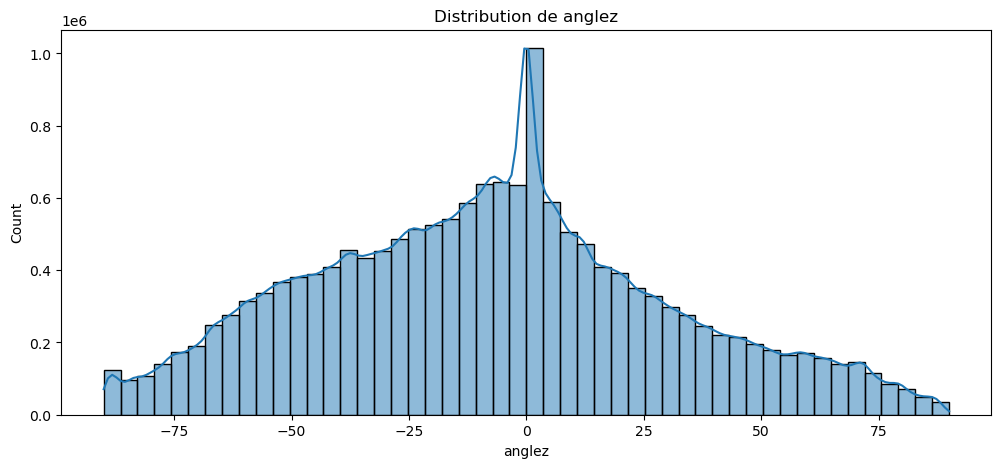

c:\Users\maell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


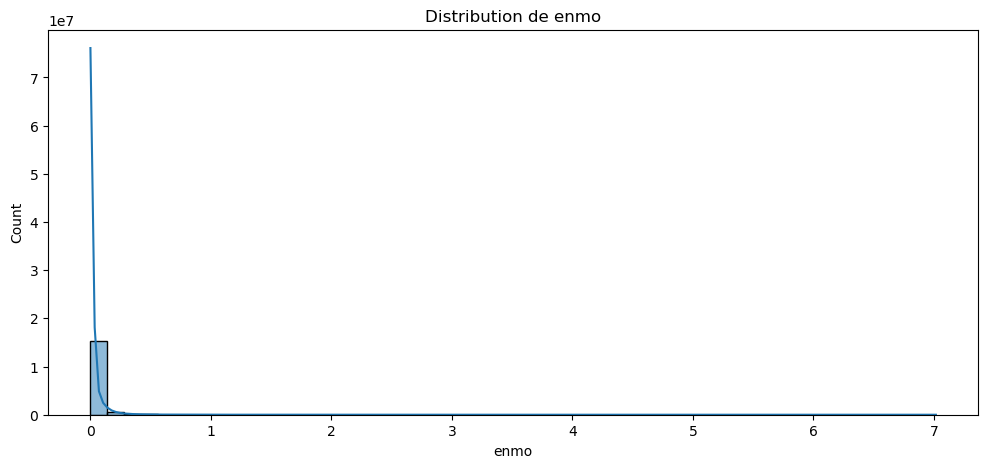

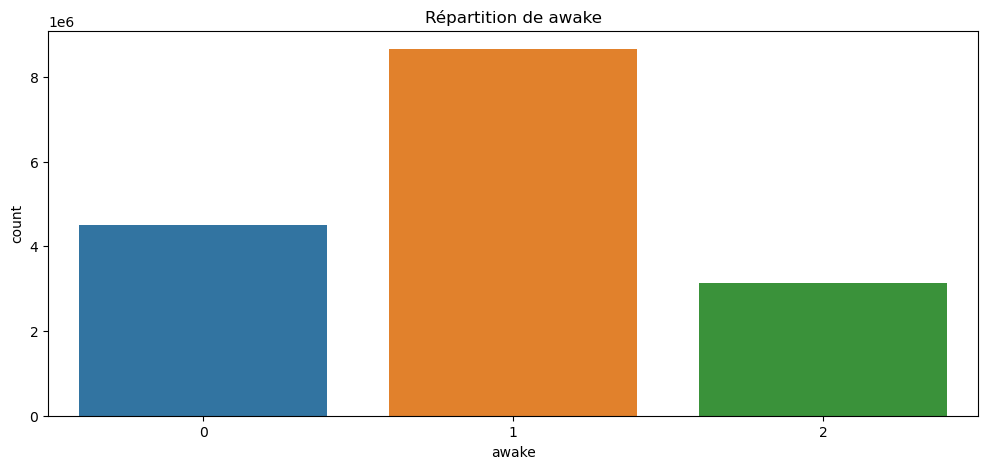

In [ ]:
# Exploration des données
plt.figure(figsize=(12, 5))
sns.histplot(df['anglez'], kde=True, bins=50)
plt.title("Distribution de anglez")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df['enmo'], kde=True, bins=50)
plt.title("Distribution de enmo")
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(x=df['awake'])
plt.title("Répartition de awake")
plt.show()

In [ ]:
# Ajouter les variances de anglez et enmo sur une fenêtre de 5 pas

df['anglez_var'] = df['anglez'].rolling(window=5, min_periods=1).var().fillna(0)
df['enmo_var'] = df['enmo'].rolling(window=5, min_periods=1).var().fillna(0)


# Sélection des features et de la cible
features = ['anglez', 'enmo', 'anglez_var', 'enmo_var']
X = df[features]
y = df['awake']

In [ ]:
# Standardisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Séparation des données en train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Création du modèle Random Forest avec une profondeur maximale de 5
clf = RandomForestClassifier(max_depth=10, min_samples_split=8, min_samples_leaf=2, n_estimators=150, oob_score=True, random_state=0)

clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, min_samples_leaf=2, min_samples_split=8,
                       n_estimators=150, oob_score=True, random_state=0)

In [ ]:
# 📌 Prédiction et évaluation
pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, pred))

In [ ]:
pred = clf.predict(X_test)

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy:.2f}")

# Obtenir le rapport sous forme de dictionnaire
report_dict = classification_report(y_true=y_test, y_pred=pred, output_dict=True)

# Convertir en DataFrame pour affichage clair
df = pd.DataFrame(report_dict).transpose()

# Afficher le tableau
print(df)

#classification_report(y_true=y_test, y_pred=pred)

Accuracy: 0.77
              precision    recall  f1-score       support
0              0.762586  0.895292  0.823628  9.008640e+05
1              0.770032  0.922003  0.839193  1.731984e+06
2              0.873349  0.176774  0.294032  6.251160e+05
accuracy       0.771627  0.771627  0.771627  7.716273e-01
macro avg      0.801989  0.664689  0.652284  3.257964e+06
weighted avg   0.787797  0.771627  0.730287  3.257964e+06


In [ ]:
clf.apply(X_train)

array([[20, 30, 44, ..., 46, 28, 43],
       [55, 55, 62, ..., 61, 54, 61],
       [28, 16, 37, ..., 51, 30, 59],
       ...,
       [31, 28, 27, ..., 61, 16, 58],
       [20, 15, 40, ..., 44, 27, 40],
       [12, 21,  5, ..., 23,  6, 21]], dtype=int64)

In [ ]:
clf.get_params(deep=True)

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 7,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 8,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 150,
 'n_jobs': None,
 'oob_score': True,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

In [ ]:
# clf.set_params(max_depth=12, min_samples_split=10, min_samples_leaf=5, n_estimators=200, oob_score=True)
# print(classification_report(y_test, pred))
# print(f"Accuracy: {accuracy_score(y_test, pred):.2f}")

              precision    recall  f1-score   support

           0       0.74      0.90      0.81    900864
           1       0.77      0.91      0.83   1731984
           2       0.96      0.13      0.24    625116

    accuracy                           0.76   3257964
   macro avg       0.82      0.65      0.63   3257964
weighted avg       0.80      0.76      0.71   3257964

Accuracy: 0.76
